# Does HFTD Eligibility Predict SGIP Battery Funding?

**Question:** Among residential battery storage applicants to California's Self-Generation
Incentive Program (SGIP) in PG&E territory, are applicants in a High Fire-Threat District
(HFTD Tier 2/3), who qualify for enhanced incentives, more likely to reach funded (`Paid`)
status than non-HFTD applicants in the same zip code who applied at the same time?

**Data:**
- SGIP Weekly Statewide Report: application-level data, downloaded from the SGIP website
- U.S. Census Bureau ACS 5-year estimates (2020–2024): housing units and median household
  income by ZIP Code Tabulation Area (ZCTA), from the Census Data API

See `plan.md` for the full analysis plan.

## 1. Setup

Imports and constants. The Census API key is read from a `.env` file (excluded from the repo
by `.gitignore`). To rerun this notebook, create a `.env` file next to it containing:

```
CENSUS_API_KEY=your_key_here
```

A free key can be requested at https://api.census.gov/data/key_signup.html.

In [1]:
import os
import re
from pathlib import Path

import pandas as pd
import requests
from dotenv import load_dotenv

# Load variables from .env into the environment, then read the Census key
load_dotenv()
CENSUS_API_KEY = os.getenv("CENSUS_API_KEY")
if not CENSUS_API_KEY:
    raise RuntimeError("CENSUS_API_KEY not found. Add it to a .env file (see above).")

# Folder for downloaded raw files (gitignored)
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

# SGIP report URL: always serves the latest weekly snapshot as an .xlsx file
SGIP_REPORT_URL = "https://www.selfgenca.com/documents/reports/statewide_projects"

# ACS 5-year vintage (2024 = 2020-2024 estimates) and the variables to pull,
# mapped from Census variable codes to readable column names
ACS_YEAR = 2024
ACS_VARIABLES = {
    "B25001_001E": "housing_units",            # Total housing units
    "B19013_001E": "median_household_income",  # Median household income (2024 dollars)
}

## 2. Pull the SGIP application data

SGIP does not offer a formal API, but the report URL returns the latest weekly `.xlsx`
directly, so the notebook downloads it with `requests` and no manual download is needed.

The report is replaced every week and application statuses keep changing, so the file is
saved under its original dated filename and the snapshot date is printed. Results are tied to
that snapshot. If a file with the same name is already in `data/`, the download is skipped.

In [2]:
def download_sgip_report(url, data_dir):
    """Download the current SGIP weekly report and return its local path.

    Parameters
    ----------
    url : str
        SGIP report URL that serves the latest .xlsx snapshot.
    data_dir : Path
        Folder where the file is saved.
    """
    # stream=True: read the headers (to get the dated filename) before downloading the body;
    # timeout=120: seconds to wait for the server before giving up
    with requests.get(url, stream=True, timeout=120) as response:
        response.raise_for_status()
        # Header looks like: attachment; filename="Weekly Statewide Report_09_27_2026(posted 09_27_26).xlsx"
        disposition = response.headers["Content-Disposition"]
        filename = re.search(r'filename="(.+?)"', disposition).group(1)
        local_path = data_dir / filename

        if local_path.exists():
            print(f"Already downloaded: {filename}")
            return local_path

        with open(local_path, "wb") as file:
            # chunk_size=1 MB: write the ~25 MB file in pieces rather than holding it in memory
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                file.write(chunk)
    print(f"Downloaded: {filename}")
    return local_path


sgip_path = download_sgip_report(SGIP_REPORT_URL, DATA_DIR)

# Snapshot date is the first MM_DD_YYYY in the filename
snapshot_date = pd.to_datetime(
    re.search(r"\d{2}_\d{2}_\d{4}", sgip_path.name).group(), format="%m_%d_%Y"
)
print(f"SGIP snapshot date: {snapshot_date:%B %d, %Y}")

Already downloaded: Weekly Statewide Report_09_27_2026(posted 09_27_26).xlsx
SGIP snapshot date: September 27, 2026


The data is on the first sheet. Rows 1–3 are a title, a date stamp and a blank row, so the
column headers are on Excel row 4 (`header=3`, counting from zero).

In [3]:
# sheet_name=0: first sheet (the data; the second sheet is a field dictionary)
# header=3: column names are on Excel row 4
sgip_raw = pd.read_excel(sgip_path, sheet_name=0, header=3)

print(f"{len(sgip_raw):,} rows, {sgip_raw.shape[1]} columns")
sgip_raw.head()

106,585 rows, 51 columns


,SGIP Administrator,Application Code,Program Year,Step,Budget Category,Fully Qualified State,Equipment Type,Rated Capacity [kW],Energy Storage Capacity (kWh),Fuel Type,...,Cancelled Date,CSI Rating,Advance Payment Program (AB 209),Total Eligible Project Cost - Solar,Total Eligible Project Cost - Storage,Solar Array Manufacturers,Solar Inverter Manufacturers,Funding Source,"Located in HFTD (Tier 2, Tier 3)",Experienced Two PSPS Events (True/False)
0,Southern California Edison,NaN,NaN,NaN,NaN,Cancelled,Electrochemical Storage,750.0,1500.0,NaN,...,05/04/17,NaN,NaN,NaN,NaN,NaN,NaN,Ratepayer,NaN,NaN
1,Southern California Edison,NaN,NaN,NaN,NaN,Cancelled,Electrochemical Storage,125.0,250.0,NaN,...,05/04/17,NaN,NaN,NaN,NaN,NaN,NaN,Ratepayer,NaN,NaN
2,Center for Sustainable Energy,NaN,NaN,NaN,NaN,Cancelled,Electrochemical Storage,261.0,522.0,NaN,...,06/01/17,NaN,NaN,NaN,NaN,NaN,NaN,Ratepayer,NaN,NaN
3,LA Dept. of Water and Power,LA-SGIP-2025-0001,2025.0,6.0,Residential Solar and Storage Equity - AB 209,RRF Technical Review,Electrochemical Storage,23.0,26.4,NaN,...,NaN,11.050649,Yes,48938.59,41485.71,Mission Solar Energy LLC,Tesla Inc.,State,Tier 2,Not Applicable
4,LA Dept. of Water and Power,LA-SGIP-2025-0002,2025.0,6.0,Residential Solar and Storage Equity - AB 209,RRF Suspended,Electrochemical Storage,34.5,39.6,NaN,...,NaN,23.566935,Yes,104367.86,47142.86,Tesla Inc.,Tesla Inc.,State,Not Applicable,Not Applicable


## 3. Pull Census ACS data by ZCTA

The Census Data API returns JSON: a list of rows whose first row is the column headers.
Since the 2020 ACS, ZCTAs cannot be filtered by state in the request, so all ZCTAs
nationwide are pulled here. The data is narrowed to California in the cleaning step.

In [4]:
def fetch_acs_zcta(variables, year, api_key):
    """Pull ACS 5-year estimates for every ZCTA and return them as a DataFrame.

    Parameters
    ----------
    variables : dict
        Census variable codes mapped to the column names to use.
    year : int
        ACS 5-year vintage (e.g. 2024 = 2020-2024 estimates).
    api_key : str
        Census Data API key.
    """
    url = f"https://api.census.gov/data/{year}/acs/acs5"
    params = {
        "get": ",".join(variables),                # variables to return
        "for": "zip code tabulation area:*",       # geography: all ZCTAs
        "key": api_key,
    }
    # timeout=120: seconds to wait for the server before giving up
    response = requests.get(url, params=params, timeout=120)
    response.raise_for_status()

    header, *rows = response.json()
    acs = pd.DataFrame(rows, columns=header)
    return acs.rename(columns={**variables, "zip code tabulation area": "zcta"})


acs_raw = fetch_acs_zcta(ACS_VARIABLES, ACS_YEAR, CENSUS_API_KEY)

print(f"{len(acs_raw):,} ZCTAs")
acs_raw.head()

33,772 ZCTAs


,housing_units,median_household_income,zcta
0,7570,19454,00601
1,17610,21420,00602
2,26239,20933,00603
3,2681,20992,00606
4,12636,24496,00610


## 4. Clean the SGIP data

The sample is narrowed one filter at a time, and the number of rows left after each step is
recorded so every drop can be traced:

1. **PG&E only**: the research question covers PG&E territory, which also contains Ava's
   service area.
2. **Residential sectors**: `Residential`, `Single Family`, `Multifamily`.
3. **Storage projects**: `Energy Storage Capacity (kWh)` is recorded.
4. **Drop `RRF Rejected`**: these applications were rejected at intake and never assigned a
   budget, so they never had a chance to be funded.
5. **Program Year 2024 or later**: CPUC Decision 24-03-071 / AB 209 restructured the
   residential equity budgets in 2024. Keeping only the new rules avoids mixing two
   eligibility regimes.
6. **HFTD status recorded**: drop rows where `Located in HFTD` is blank.
7. **Received before 2026**: applications received in 2026 are almost all still in review
   (Paid rate near 0%). Keeping them would make whichever group applied later look less
   successful just because of timing.

`Date Received` is stored as text like `01/02/24 10:59:54.708805 PST` (or `PDT`), so the
timezone label is stripped before parsing.

In [5]:
# Long SGIP column names used several times below
HFTD_COL = "Located in HFTD (Tier 2, Tier 3)"
PSPS_COL = "Experienced Two PSPS Events (True/False)"

RESIDENTIAL_SECTORS = ["Residential", "Single Family", "Multifamily"]
HFTD_STATUSES = ["Tier 2", "Tier 3", "Not Applicable"]
FIRST_PROGRAM_YEAR = 2024                       # first year under D.24-03-071 / AB 209 rules
RECEIVED_CUTOFF = pd.Timestamp("2026-01-01")    # later applications are mostly unresolved


def parse_received_date(date_text):
    """Convert SGIP 'Date Received' strings to timestamps.

    Parameters
    ----------
    date_text : pd.Series
        Raw strings such as '01/02/24 10:59:54.708805 PST'.
    """
    # Remove the trailing PST/PDT label, which pandas cannot parse with a fixed format
    without_zone = date_text.str.replace(r"\s+P[SD]T$", "", regex=True)
    # errors="coerce": unparseable strings become NaT so they can be counted, not crash
    return pd.to_datetime(without_zone, format="%m/%d/%y %H:%M:%S.%f", errors="coerce")


def apply_filters(df, filters):
    """Apply filters in order and record the rows left after each one.

    Parameters
    ----------
    df : pd.DataFrame
        Data to filter.
    filters : list of (str, callable)
        Each item is a step description and a function that takes the current
        DataFrame and returns a True/False mask of rows to keep.

    Returns the filtered DataFrame and a table of row counts by step.
    """
    log = [("Raw SGIP report", len(df))]
    for description, keep in filters:
        df = df[keep(df)]
        log.append((description, len(df)))

    funnel = pd.DataFrame(log, columns=["step", "rows_remaining"])
    # Rows removed by each step (zero for the starting row)
    funnel["rows_dropped"] = (-funnel["rows_remaining"].diff()).fillna(0).astype(int)
    return df, funnel

In [6]:
sgip = sgip_raw.assign(received=parse_received_date(sgip_raw["Date Received"]))

sample_filters = [
    ("1. PG&E administrator",
     lambda df: df["SGIP Administrator"] == "Pacific Gas and Electric"),
    ("2. Residential sector",
     lambda df: df["Host Customer Sector"].isin(RESIDENTIAL_SECTORS)),
    ("3. Storage project (kWh recorded)",
     lambda df: df["Energy Storage Capacity (kWh)"].notna()),
    ("4. Drop RRF Rejected",
     lambda df: df["Fully Qualified State"] != "RRF Rejected"),
    (f"5. Program Year >= {FIRST_PROGRAM_YEAR}",
     lambda df: df["Program Year"] >= FIRST_PROGRAM_YEAR),
    ("6. HFTD status recorded",
     lambda df: df[HFTD_COL].isin(HFTD_STATUSES)),
    (f"7. Received before {RECEIVED_CUTOFF:%Y-%m-%d}",
     lambda df: df["received"] < RECEIVED_CUTOFF),
]

sgip_sample, filter_funnel = apply_filters(sgip, sample_filters)
filter_funnel

,step,rows_remaining,rows_dropped
0,Raw SGIP report,106585,0
1,1. PG&E administrator,47990,58595
2,2. Residential sector,43526,4464
3,3. Storage project (kWh recorded),43460,66
4,4. Drop RRF Rejected,41587,1873
5,5. Program Year >= 2024,9970,31617
6,6. HFTD status recorded,9447,523
7,7. Received before 2026-01-01,9110,337


### Analysis variables

Each application gets the variables used in the charts and regressions:

| Variable | Definition |
|---|---|
| `paid` | 1 if `Budget Classification` is `Paid` (the outcome), else 0 |
| `hftd` | 1 if HFTD Tier 2 or Tier 3, 0 if Not Applicable (the treatment) |
| `tier2`, `tier3` | Separate tier indicators, for the robustness check |
| `psps` | 1 if the household experienced two PSPS (Public Safety Power Shutoff) events, else 0. This is a second route to enhanced incentives, so it is controlled for. |
| `received_quarter` | Calendar quarter the application was received (timing control) |
| `zip5` | 5-digit zip code. A few zips are recorded as ZIP+4, so only the first 5 digits are kept. |

In [7]:
applications = pd.DataFrame({
    "application_code": sgip_sample["Application Code"],
    "zip5": sgip_sample["Zip"].astype(str).str[:5],
    "received": sgip_sample["received"],
    "received_quarter": sgip_sample["received"].dt.to_period("Q").astype(str),
    "hftd_status": sgip_sample[HFTD_COL],
    "hftd": sgip_sample[HFTD_COL].isin(["Tier 2", "Tier 3"]).astype(int),
    "tier2": sgip_sample[HFTD_COL].eq("Tier 2").astype(int),
    "tier3": sgip_sample[HFTD_COL].eq("Tier 3").astype(int),
    "psps": sgip_sample[PSPS_COL].eq("Yes").astype(int),
    "budget_classification": sgip_sample["Budget Classification"],
    "paid": sgip_sample["Budget Classification"].eq("Paid").astype(int),
}).reset_index(drop=True)

# Sanity checks: one row per application, and no missing key fields
assert applications["application_code"].is_unique
assert applications[["zip5", "received", "budget_classification"]].notna().all().all()

print(f"{len(applications):,} applications in {applications['zip5'].nunique():,} zip codes")
applications.groupby("hftd_status").agg(
    applications=("paid", "size"),
    paid_rate=("paid", "mean"),
    psps_share=("psps", "mean"),
).round(3)

9,110 applications in 711 zip codes


,applications,paid_rate,psps_share
hftd_status,,,
Not Applicable,6589,0.353,0.177
Tier 2,1751,0.509,0.572
Tier 3,770,0.453,0.694


Zip code fixed effects compare HFTD and non-HFTD applicants **within the same zip**, so only
zips that contain both kinds of applicants provide the identifying variation.

In [8]:
# For each zip: lowest and highest value of hftd (0/0 = none, 1/1 = all, 0/1 = both)
zip_hftd_range = applications.groupby("zip5")["hftd"].agg(["min", "max"])
zips_with_both = ((zip_hftd_range["min"] == 0) & (zip_hftd_range["max"] == 1)).sum()

print(f"Zips with any HFTD applicant:     {(zip_hftd_range['max'] == 1).sum():,}")
print(f"Zips with any non-HFTD applicant: {(zip_hftd_range['min'] == 0).sum():,}")
print(f"Zips with both (identifying):     {zips_with_both:,}")

Zips with any HFTD applicant:     351
Zips with any non-HFTD applicant: 594
Zips with both (identifying):     234


## 5. Clean the Census data and merge

- Keep California ZCTAs (codes `90000`–`96199`).
- Convert estimates from text to numbers. The Census API reports estimates it cannot compute
  as large negative codes (e.g. `-666666666` for median income in very small ZCTAs). These
  are set to missing.
- Merge onto the applications by 5-digit zip. Zip codes and ZCTAs are not identical: some
  zips, such as PO-box-only zips, have no ZCTA. Unmatched applications are counted below.

In [9]:
CA_ZCTA_RANGE = ("90000", "96199")   # first and last California ZCTA codes

acs = acs_raw[acs_raw["zcta"].between(*CA_ZCTA_RANGE)].copy()
for column in ACS_VARIABLES.values():
    acs[column] = pd.to_numeric(acs[column])
    # mask(...): replace negative "cannot compute" codes with NaN
    acs[column] = acs[column].mask(acs[column] < 0)

print(f"{len(acs):,} California ZCTAs; "
      f"{acs['median_household_income'].isna().sum()} with no median income estimate")

# how="left": keep every application, even if its zip has no ZCTA match;
# validate="many_to_one": each ZCTA must appear only once in the Census data;
# indicator=True: adds a _merge column showing whether each row matched
applications = applications.merge(
    acs, how="left", left_on="zip5", right_on="zcta",
    validate="many_to_one", indicator=True,
)
unmatched = applications["_merge"] == "left_only"
print(f"Applications with no matching ZCTA: {unmatched.sum():,} "
      f"({applications.loc[unmatched, 'zip5'].nunique()} zips)")
applications = applications.drop(columns=["zcta", "_merge"])

1,802 California ZCTAs; 212 with no median income estimate
Applications with no matching ZCTA: 14 (11 zips)


### Zip-level summary (secondary question)

The applications are collapsed to one row per zip: the number of storage applications, the
share of them in an HFTD, and applications per 1,000 housing units. The rate is left missing
for zips with no ZCTA match or zero housing units.

In [10]:
zip_summary = (
    applications.groupby("zip5")
    .agg(
        applications=("paid", "size"),
        share_hftd=("hftd", "mean"),
        housing_units=("housing_units", "first"),
        median_household_income=("median_household_income", "first"),
    )
    .reset_index()
)
# where(... > 0): treat zero housing units as missing so the rate is not divided by zero
zip_summary["applications_per_1000_units"] = (
    1000 * zip_summary["applications"]
    / zip_summary["housing_units"].where(zip_summary["housing_units"] > 0)
)

zip_summary.describe().round(2)

,applications,share_hftd,housing_units,median_household_income,applications_per_1000_units
count,711.00,711.00,700.00,679.00,697.00
mean,12.81,0.31,8550.77,108753.08,2.90
std,14.44,0.40,7289.44,48929.40,4.83
min,1.00,0.00,0.00,13333.00,0.04
25%,3.00,0.00,1851.00,72467.50,0.81
50%,8.00,0.00,6903.00,98125.00,1.60
75%,18.00,0.67,13823.00,131321.50,3.11
max,91.00,1.00,31396.00,250001.00,62.50


## 6. Charts

Every chart uses the same color for each HFTD status. The colors come from a palette
checked for colorblind readability, and bars carry value labels so color is never the only
cue. Error bars are 95% confidence intervals for a proportion
(p ± 1.96·√(p(1−p)/n)).

The coefficient plot comparing regression specifications (Chart 5) is in Section 7, after the
regressions are run.

In [11]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter

# One fixed color per HFTD status, used in every chart
HFTD_COLORS = {"Not Applicable": "#2a78d6", "Tier 2": "#eb6834", "Tier 3": "#1baf7a"}
HFTD_LABELS = {"Not Applicable": "Not in HFTD", "Tier 2": "HFTD Tier 2", "Tier 3": "HFTD Tier 3"}
INK, MUTED_INK, GRID = "#0b0b0b", "#52514e", "#e4e3df"   # text, secondary text, gridlines

SGIP_SOURCE = (f"Source: SGIP Weekly Statewide Report ({snapshot_date:%m/%d/%Y} snapshot). "
               "PG&E residential storage applications received 2024–2025.")
ACS_SOURCE = f"U.S. Census Bureau, ACS 5-year estimates {ACS_YEAR - 4}–{ACS_YEAR}."


def style_axes(ax, title, xlabel, ylabel, source):
    """Apply shared chart styling: title, axis labels, light grid, and a source note.

    Parameters
    ----------
    ax : matplotlib Axes
        Axes to style.
    title, xlabel, ylabel : str
        Chart title and axis labels (include units).
    source : str or None
        Data source note printed under the chart; None skips it.
    """
    ax.set_title(title, loc="left", fontsize=13, color=INK, pad=12)
    ax.set_xlabel(xlabel, color=MUTED_INK)
    ax.set_ylabel(ylabel, color=MUTED_INK)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(MUTED_INK)
    ax.tick_params(colors=MUTED_INK)
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)   # draw gridlines behind the data
    if source is None:
        return
    # Anchor at the axes' bottom-left corner, then shift 45 points down (below the x-axis
    # label) so the note sits at the same distance regardless of panel height
    ax.annotate(source, xy=(0, 0), xycoords="axes fraction",
                xytext=(0, -45), textcoords="offset points",
                fontsize=8, color=MUTED_INK, va="top")


def paid_rate_with_ci(df, group_cols):
    """Paid rate, count, and 95% confidence half-width for each group.

    Parameters
    ----------
    df : pd.DataFrame
        Application-level data with a 0/1 'paid' column.
    group_cols : str or list of str
        Column(s) to group by.
    """
    summary = df.groupby(group_cols)["paid"].agg(paid_rate="mean", n="size").reset_index()
    # 1.96 = z-value for a 95% interval
    summary["ci95"] = 1.96 * (summary["paid_rate"] * (1 - summary["paid_rate"]) / summary["n"]) ** 0.5
    return summary

### Chart 1: Paid rate by HFTD status

The raw comparison, with no controls. This is the gap the regressions will test.

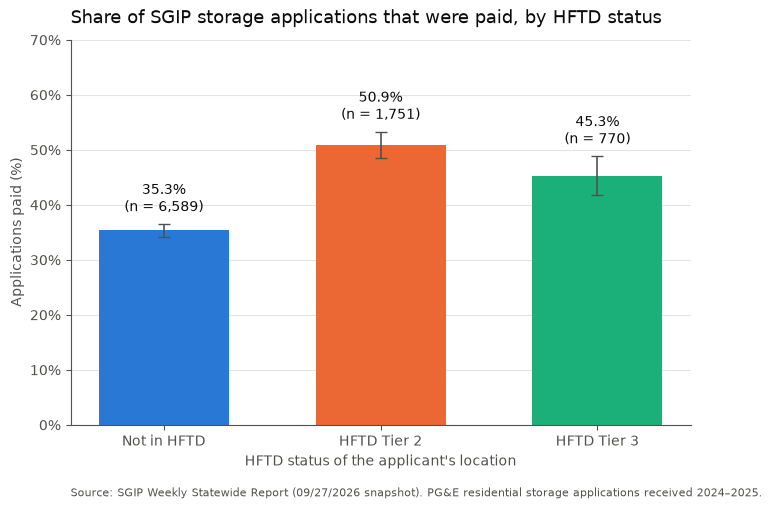

In [12]:
status_rates = paid_rate_with_ci(applications, "hftd_status")

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    [HFTD_LABELS[s] for s in status_rates["hftd_status"]],
    status_rates["paid_rate"],
    yerr=status_rates["ci95"],
    color=[HFTD_COLORS[s] for s in status_rates["hftd_status"]],
    width=0.6,
    capsize=4,                                    # error-bar cap width in points
    error_kw={"ecolor": MUTED_INK, "elinewidth": 1.2},
)
# Value and sample-size label above each bar (bar.get_x() + width/2 = bar center)
for bar, (rate, n, ci) in zip(bars, status_rates[["paid_rate", "n", "ci95"]].itertuples(index=False)):
    ax.text(bar.get_x() + bar.get_width() / 2, rate + ci + 0.015,
            f"{rate:.1%}\n(n = {n:,})", ha="center", va="bottom", fontsize=10, color=INK)

ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))   # xmax=1: values are 0–1 shares
ax.set_ylim(0, 0.7)
style_axes(ax, "Share of SGIP storage applications that were paid, by HFTD status",
           "HFTD status of the applicant's location", "Applications paid (%)", SGIP_SOURCE)
plt.show()

### Chart 2: Timing, the main confounder

The top panel shows the Paid rate by the quarter each application was received. The bottom
panel shows when each group applied, as the share of that group's applications received in
each quarter. If HFTD applications arrived earlier, when every group's Paid rate was higher,
part of the raw gap in Chart 1 is a timing effect. This is why the regressions control for
the quarter an application was received.

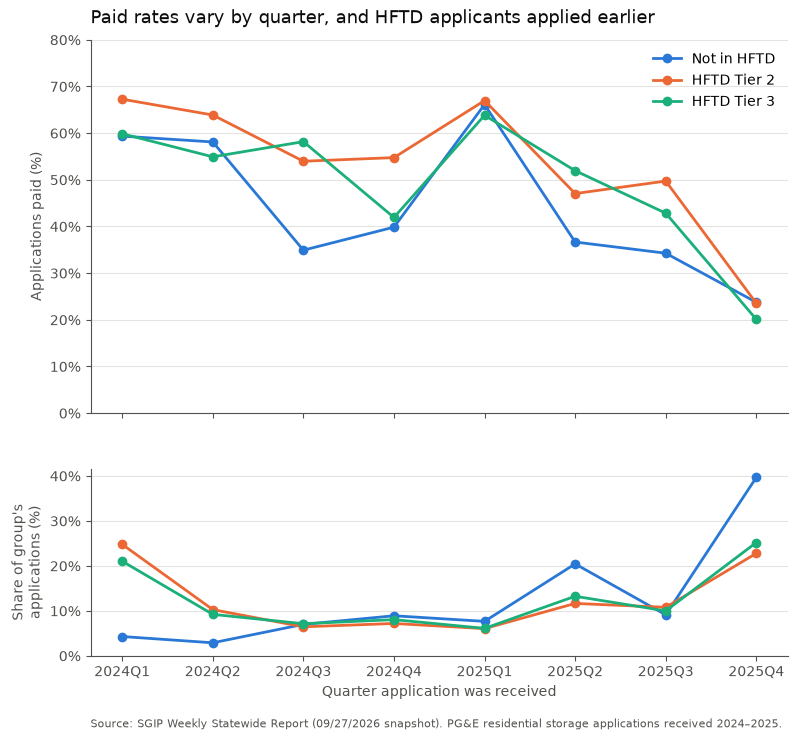

In [13]:
quarter_rates = paid_rate_with_ci(applications, ["received_quarter", "hftd_status"])
# Share of each status's applications that arrived in each quarter
quarter_rates["share_of_status"] = (
    quarter_rates["n"] / quarter_rates.groupby("hftd_status")["n"].transform("sum")
)
quarters = sorted(applications["received_quarter"].unique())

# sharex=True: both panels use the same quarter axis; height_ratios: top panel twice as tall
fig, (ax_rate, ax_share) = plt.subplots(
    2, 1, figsize=(9, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
)
for status, color in HFTD_COLORS.items():
    rows = quarter_rates[quarter_rates["hftd_status"] == status].set_index("received_quarter").reindex(quarters)
    # linewidth/markersize in points; zorder=3 draws lines above the gridlines
    ax_rate.plot(quarters, rows["paid_rate"], color=color, linewidth=2,
                 marker="o", markersize=6, label=HFTD_LABELS[status], zorder=3)
    ax_share.plot(quarters, rows["share_of_status"], color=color, linewidth=2,
                  marker="o", markersize=6, label=HFTD_LABELS[status], zorder=3)

ax_rate.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax_rate.set_ylim(0, 0.8)
ax_rate.legend(frameon=False, loc="upper right")
# source=None: the source note goes under the bottom panel only
style_axes(ax_rate, "Paid rates vary by quarter, and HFTD applicants applied earlier",
           "", "Applications paid (%)", source=None)

ax_share.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax_share.set_ylim(0, None)
style_axes(ax_share, "", "Quarter application was received",
           "Share of group's\napplications (%)", SGIP_SOURCE)
plt.show()

### Chart 3: Paid rate by HFTD status and PSPS experience

Households that had two Public Safety Power Shutoff (PSPS) events can qualify for enhanced
incentives even outside an HFTD. If non-HFTD households with two PSPS events are paid at
about the same rate as HFTD households, that suggests eligibility for enhanced incentives in
general, not HFTD location specifically, is what predicts funding.

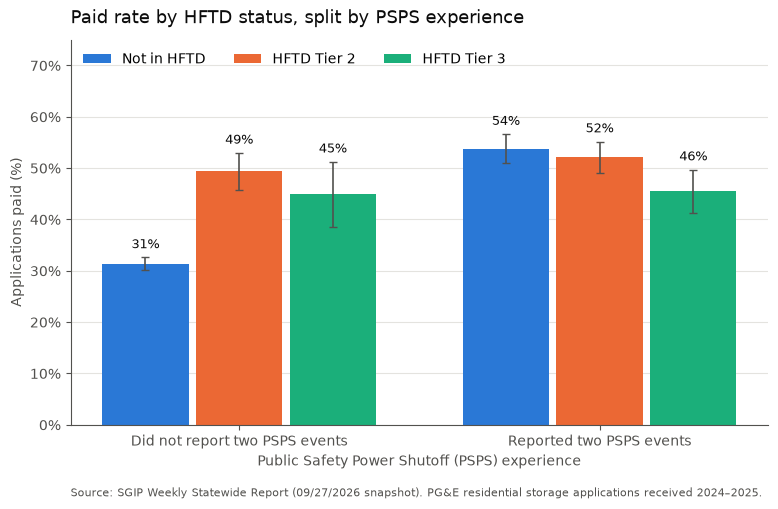

In [14]:
psps_rates = paid_rate_with_ci(applications, ["psps", "hftd_status"])
PSPS_GROUPS = {0: "Did not report two PSPS events", 1: "Reported two PSPS events"}
BAR_WIDTH = 0.26   # width of each bar; three bars per PSPS group

fig, ax = plt.subplots(figsize=(9, 5))
for offset, (status, color) in zip([-1, 0, 1], HFTD_COLORS.items()):
    rows = psps_rates[psps_rates["hftd_status"] == status].set_index("psps").reindex(list(PSPS_GROUPS))
    # x position: group index shifted left/right so the three bars sit side by side
    positions = [i + offset * BAR_WIDTH for i in range(len(PSPS_GROUPS))]
    ax.bar(positions, rows["paid_rate"], yerr=rows["ci95"], width=BAR_WIDTH * 0.92,
           color=color, label=HFTD_LABELS[status], capsize=3,
           error_kw={"ecolor": MUTED_INK, "elinewidth": 1.2})
    for x, rate, ci in zip(positions, rows["paid_rate"], rows["ci95"]):
        ax.text(x, rate + ci + 0.012, f"{rate:.0%}", ha="center", va="bottom", fontsize=9, color=INK)

ax.set_xticks(range(len(PSPS_GROUPS)), list(PSPS_GROUPS.values()))
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.set_ylim(0, 0.75)
ax.legend(frameon=False, ncols=3, loc="upper left")   # ncols=3: legend in one row
style_axes(ax, "Paid rate by HFTD status, split by PSPS experience",
           "Public Safety Power Shutoff (PSPS) experience", "Applications paid (%)", SGIP_SOURCE)
plt.show()

### Chart 4: Applications per 1,000 housing units vs. HFTD share (secondary question)

Each point is a zip code. The y-axis is on a log scale because a few small zips have very high
rates. Zips with no ZCTA match or zero housing units are left out.

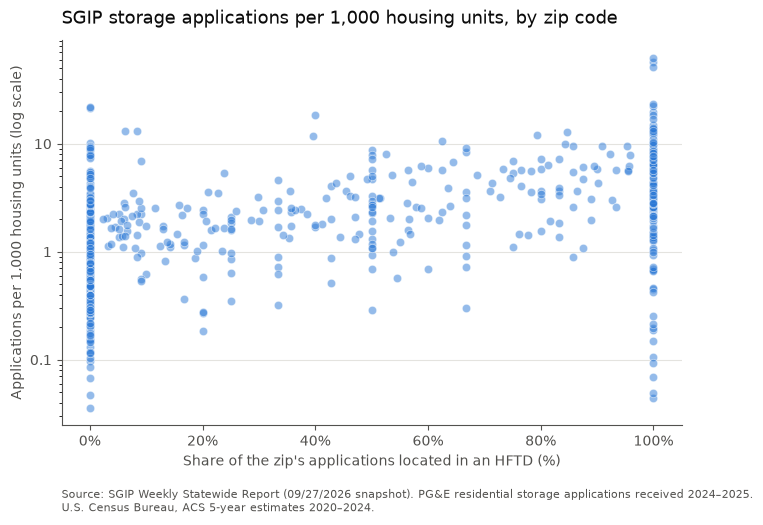

697 zips plotted


In [15]:
zips_with_rate = zip_summary.dropna(subset=["applications_per_1000_units"])

fig, ax = plt.subplots(figsize=(8, 5))
# alpha=0.5: semi-transparent so overlapping points are visible; s = marker area in points^2;
# edgecolor="white": thin ring separates overlapping points
ax.scatter(zips_with_rate["share_hftd"], zips_with_rate["applications_per_1000_units"],
           color=HFTD_COLORS["Not Applicable"], alpha=0.5, s=36, edgecolor="white", linewidth=0.6)
ax.set_yscale("log")
# Show log-axis ticks as plain numbers (0.1, 1, 10) instead of powers of ten
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:g}"))
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1))
style_axes(ax, "SGIP storage applications per 1,000 housing units, by zip code",
           "Share of the zip's applications located in an HFTD (%)",
           "Applications per 1,000 housing units (log scale)",
           SGIP_SOURCE + "\n" + ACS_SOURCE)
plt.show()

print(f"{len(zips_with_rate)} zips plotted")

## 7. Statistical tests

### Raw gap: two-proportion z-test

Before adding any controls: is the difference in Paid rates between HFTD (Tier 2/3) and
non-HFTD applicants larger than chance would produce?

In [16]:
from scipy.stats import norm


def two_proportion_ztest(successes_a, n_a, successes_b, n_b):
    """Two-sided z-test for a difference between two proportions (pooled variance).

    Parameters
    ----------
    successes_a, n_a : int
        Number of successes and total observations in group A.
    successes_b, n_b : int
        Number of successes and total observations in group B.

    Returns the difference (A minus B), the z statistic, and the p-value.
    """
    rate_a, rate_b = successes_a / n_a, successes_b / n_b
    pooled_rate = (successes_a + successes_b) / (n_a + n_b)
    std_error = (pooled_rate * (1 - pooled_rate) * (1 / n_a + 1 / n_b)) ** 0.5
    z_stat = (rate_a - rate_b) / std_error
    p_value = 2 * norm.sf(abs(z_stat))   # sf = 1 - CDF; times 2 for a two-sided test
    return rate_a - rate_b, z_stat, p_value


hftd_paid = applications.groupby("hftd")["paid"].agg(["sum", "size"])
difference, z_stat, p_value = two_proportion_ztest(
    successes_a=hftd_paid.loc[1, "sum"], n_a=hftd_paid.loc[1, "size"],   # HFTD
    successes_b=hftd_paid.loc[0, "sum"], n_b=hftd_paid.loc[0, "size"],   # not HFTD
)
print(f"HFTD minus non-HFTD Paid rate: {difference * 100:+.1f} percentage points "
      f"(z = {z_stat:.2f}, p = {p_value:.2g})")

HFTD minus non-HFTD Paid rate: +13.9 percentage points (z = 12.14, p = 6.4e-34)


### Regressions

All models are **linear probability models** (OLS with a 0/1 outcome), so each coefficient
is a change in the probability of being paid. For example, 0.05 = 5 percentage points.
Standard errors are **clustered by zip code**, because applicants in the same zip share
installers, local outreach and budget conditions, so their outcomes are not independent.

| Model | Specification | Purpose |
|---|---|---|
| (1) | `paid ~ hftd` | Raw gap, matches Chart 1 |
| (2) | `+ psps + median income \| quarter FE` | Robustness (a): timing and PSPS controls, but **no zip FE**. Zip median household income (ACS, in $10,000s) is the only control for neighborhood. |
| (3) | `paid ~ hftd + psps \| zip FE + quarter FE` | **Main specification** from `plan.md` |
| (4) | `paid ~ tier2 + tier3 + psps \| zip FE + quarter FE` | Robustness (b): Tier 2 and Tier 3 separately |
| (5) | `paid ~ hftd_no_psps + hftd_with_psps + psps \| zip FE + quarter FE` | **Added after Chart 3** (not in the original plan): lets the HFTD effect differ for households with and without two PSPS events |

FE = fixed effects. In model (5), `hftd_no_psps` is the HFTD effect among households with no
PSPS eligibility, and `hftd_with_psps` is the HFTD effect among households that already
qualify through PSPS. If eligibility through *either* route is what matters, the first should
be positive and the second near zero.

`pyfixest` drops applications that are the only one in their zip or quarter (singletons),
because a fixed effect fits them perfectly and they carry no information. That is why the
fixed-effects models have slightly fewer observations.

In [17]:
import pyfixest as pf

regression_data = applications.assign(
    income_10k=applications["median_household_income"] / 10_000,   # income in $10,000s
    hftd_no_psps=applications["hftd"] * (1 - applications["psps"]),
    hftd_with_psps=applications["hftd"] * applications["psps"],
)

# Model label -> formula. pyfixest syntax: "outcome ~ regressors | fixed effects".
# Fixed effects are written without spaces ("zip5+received_quarter") because pyfixest's
# etable() does not recognize them in the results table when spaces surround the "+".
MODEL_FORMULAS = {
    "(1) Raw gap": "paid ~ hftd",
    "(2) No zip FE": "paid ~ hftd + psps + income_10k | received_quarter",
    "(3) Main": "paid ~ hftd + psps | zip5+received_quarter",
    "(4) Tiers split": "paid ~ tier2 + tier3 + psps | zip5+received_quarter",
    "(5) By PSPS status": "paid ~ hftd_no_psps + hftd_with_psps + psps | zip5+received_quarter",
}

# vcov={"CRV1": "zip5"}: cluster-robust standard errors, clustered by zip code
models = {
    label: pf.feols(formula, data=regression_data, vcov={"CRV1": "zip5"})
    for label, formula in MODEL_FORMULAS.items()
}

/opt/anaconda3/lib/python3.14/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 118 singleton fixed effect(s) dropped from the model.
  warnings.warn(
/opt/anaconda3/lib/python3.14/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 118 singleton fixed effect(s) dropped from the model.
  warnings.warn(
/opt/anaconda3/lib/python3.14/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 118 singleton fixed effect(s) dropped from the model.
  warnings.warn(


In [18]:
COEF_LABELS = {
    "hftd": "HFTD (Tier 2 or 3)",
    "tier2": "HFTD Tier 2",
    "tier3": "HFTD Tier 3",
    "hftd_no_psps": "HFTD × no PSPS eligibility",
    "hftd_with_psps": "HFTD × PSPS eligible",
    "psps": "Two PSPS events",
    "income_10k": "Zip median income ($10k)",
    "Intercept": "Constant",
}

# _G holds the number of clusters for each clustering variable (only zip5 here)
cluster_counts = [model._G[0] for model in models.values()]

pf.etable(
    list(models.values()),
    labels=COEF_LABELS,
    felabels={"zip5": "Zip code FE", "received_quarter": "Quarter received FE"},
    model_heads=list(models),
    custom_model_stats={"Zip clusters": cluster_counts},
    coef_fmt="b:.3f* \n (se:.3f)",   # coefficient with stars, standard error below
    notes="Linear probability models. Outcome: application Paid (0/1). "
          "Standard errors clustered by zip code in parentheses.",
)

GT(_tbl_data=   __index_level_0__           __index_level_1__                      0  \
0               coef          HFTD (Tier 2 or 3)  0.139*** <br> (0.015)   
1               coef             Two PSPS events                          
2               coef    Zip median income ($10k)                          
3               coef                 HFTD Tier 2                          
4               coef                 HFTD Tier 3                          
5               coef  HFTD × no PSPS eligibility                          
6               coef        HFTD × PSPS eligible                          
7               coef                    Constant  0.353*** <br> (0.010)   
8                 fe         Quarter received FE                      -   
9                 fe                 Zip code FE                      -   
10             stats                Zip clusters                    711   
11             stats                Observations                  9,110   
12             stats                          R²                  0.016   

                        1                      2                      3  \
0      0.010 <br> (0.015)   0.057** <br> (0.019)                          
1   0.134*** <br> (0.016)  0.173*** <br> (0.018)  0.175*** <br> (0.018)   
2   0.006*** <br> (0.001)                                                 
3                                                 0.069*** <br> (0.020)   
4                                                    0.022 <br> (0.028)   
5                                                                         
6                                                                         
7                                                                         
8                       x                      x                      x   
9                       -                      x                      x   
10                    679                    593                    593   
11                  9,065                  8,992                  8,992   
12                   0.11                  0.202                  0.202   

                        4  
0                          
1   0.249*** <br> (0.023)  
2                          
3                          
4                          
5   0.144*** <br> (0.027)  
6     -0.019 <br> (0.023)  
7                          
8                       x  
9                       x  
10                    593  
11                  8,992  
12                  0.205  , _body=<great_tables._gt_data.Body object at 0x17c835160>, _boxhead=Boxhead([ColInfo(var='__index_level_0__', type=<ColInfoTypeEnum.row_group: 3>, column_label='__index_level_0__', column_align='center', column_width=None), ColInfo(var='__index_level_1__', type=<ColInfoTypeEnum.stub: 2>, column_label='__index_level_1__', column_align='center', column_width=None), ColInfo(var='0', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='(1)'), column_align='center', column_width=None), ColInfo(var='1', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='(2)'), column_align='center', column_width=None), ColInfo(var='2', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='(3)'), column_align='center', column_width=None), ColInfo(var='3', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='(4)'), column_align='center', column_width=None), ColInfo(var='4', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='(5)'), column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x17c783ed0>, _spanners=Spanners([SpannerInfo(spanner_id='paid', spanner_level=2, spanner_label=Html(text='paid'), spanner_units=None, spanner_pattern=None, vars=['0', '1', '2', '3', '4'], built=None), SpannerInfo(spanner_id='(1) Raw gap', spanner_level=1, spanner_label=Html(text='(1) Raw gap'), spanner_units=None, spanner_pattern=None, vars=['0'], built=None), SpannerInfo(spanner_id='(2) No zip FE', spanner_level=1, spanner_label=Html(text='(2) N

### Chart 5: HFTD estimate across specifications

Each point is an HFTD coefficient with its 95% confidence interval. A point to the right of
the zero line means HFTD applicants were *more* likely to be paid under that specification.

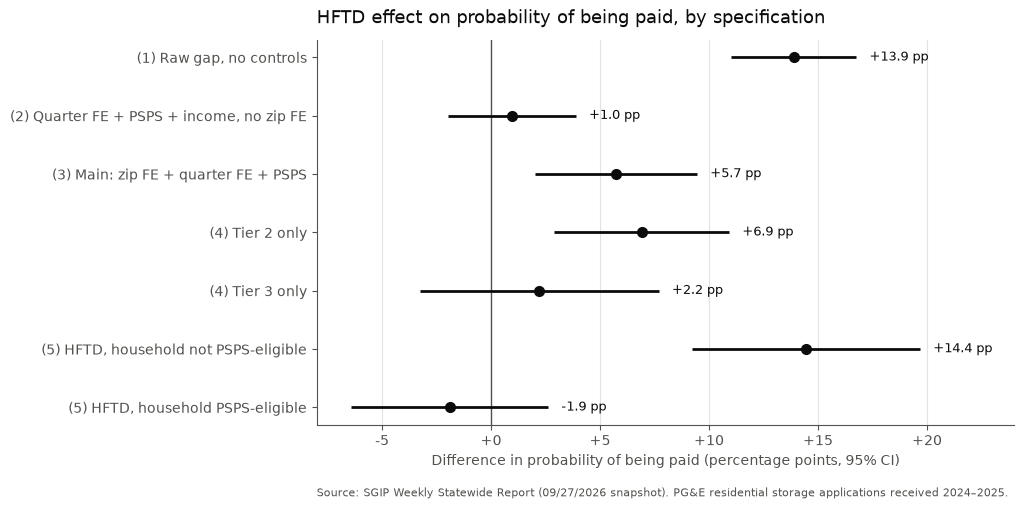

In [19]:
# (model label, coefficient name, row label on the chart), listed top to bottom
COEFFICIENTS_TO_PLOT = [
    ("(1) Raw gap", "hftd", "(1) Raw gap, no controls"),
    ("(2) No zip FE", "hftd", "(2) Quarter FE + PSPS + income, no zip FE"),
    ("(3) Main", "hftd", "(3) Main: zip FE + quarter FE + PSPS"),
    ("(4) Tiers split", "tier2", "(4) Tier 2 only"),
    ("(4) Tiers split", "tier3", "(4) Tier 3 only"),
    ("(5) By PSPS status", "hftd_no_psps", "(5) HFTD, household not PSPS-eligible"),
    ("(5) By PSPS status", "hftd_with_psps", "(5) HFTD, household PSPS-eligible"),
]

estimates = pd.DataFrame([
    {
        "row_label": row_label,
        "estimate": models[model_label].coef()[coefficient],
        # confint() returns the 95% interval as two columns: lower, upper
        "lower": models[model_label].confint().loc[coefficient].iloc[0],
        "upper": models[model_label].confint().loc[coefficient].iloc[1],
    }
    for model_label, coefficient, row_label in COEFFICIENTS_TO_PLOT
])
y_positions = range(len(estimates), 0, -1)   # first row at the top

fig, ax = plt.subplots(figsize=(9, 5))
ax.axvline(0, color=MUTED_INK, linewidth=1)   # zero = no difference
# xerr: distance from the estimate to each end of the confidence interval
ax.errorbar(
    estimates["estimate"], list(y_positions),
    xerr=[estimates["estimate"] - estimates["lower"], estimates["upper"] - estimates["estimate"]],
    fmt="o", color=INK, markersize=7, elinewidth=2, capsize=0,
)
for y, estimate, upper in zip(y_positions, estimates["estimate"], estimates["upper"]):
    ax.text(upper + 0.006, y, f"{estimate * 100:+.1f} pp", va="center", fontsize=9, color=INK)

ax.set_yticks(list(y_positions), estimates["row_label"])
# Convert the 0–1 probability scale to percentage points on the axis
ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value * 100:+.0f}"))
ax.set_xlim(-0.08, 0.24)
style_axes(ax, "HFTD effect on probability of being paid, by specification",
           "Difference in probability of being paid (percentage points, 95% CI)", "", SGIP_SOURCE)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", color=GRID, linewidth=0.8)
plt.show()

In [20]:
main_model = models["(3) Main"]
main_estimate = main_model.coef()["hftd"]
main_lower, main_upper = main_model.confint().loc["hftd"]

print(f"Main specification: HFTD applicants are {main_estimate * 100:+.1f} percentage points "
      f"more likely to be paid (95% CI {main_lower * 100:+.1f} to {main_upper * 100:+.1f}, "
      f"p = {main_model.pvalue()['hftd']:.3f}), compared with non-HFTD applicants in the same "
      f"zip code who applied in the same quarter. "
      f"N = {main_model._N:,}; {main_model._G[0]} zip clusters.")

Main specification: HFTD applicants are +5.7 percentage points more likely to be paid (95% CI +2.0 to +9.5, p = 0.003), compared with non-HFTD applicants in the same zip code who applied in the same quarter. N = 8,992; 593 zip clusters.
